In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb
import mlflow
import mlflow.xgboost
import warnings
warnings.filterwarnings('ignore')

# Load data
X = pd.read_csv('../data/processed/X_scaled.csv')
y = pd.read_csv('../data/processed/y.csv').squeeze()

# Train/validation split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("y_train shape:", y_train.shape)
print("y_val shape:", y_val.shape)

X_train shape: (16504, 70)
X_val shape: (4127, 70)
y_train shape: (16504,)
y_val shape: (4127,)


In [2]:
# Set MLflow experiment
mlflow.set_experiment("predictive_maintenance_rul")

with mlflow.start_run(run_name="xgboost_baseline"):
    
    # Define model parameters
    params = {
        'n_estimators': 200,
        'max_depth': 6,
        'learning_rate': 0.05,
        'subsample': 0.8,
        'colsample_bytree': 0.8,
        'random_state': 42
    }
    
    # Train model
    model = xgb.XGBRegressor(**params)
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        verbose=50
    )
    
    # Predict
    y_pred = model.predict(X_val)
    
    # Evaluate
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    mae = mean_absolute_error(y_val, y_pred)
    r2 = r2_score(y_val, y_pred)
    
    # Log parameters and metrics to MLflow
    mlflow.log_params(params)
    mlflow.log_metric("rmse", rmse)
    mlflow.log_metric("mae", mae)
    mlflow.log_metric("r2", r2)
    
    # Log model
    mlflow.xgboost.log_model(model, "xgboost_model")
    
    print("=" * 40)
    print("XGBoost Model Results")
    print("=" * 40)
    print(f"RMSE : {rmse:.2f} cycles")
    print(f"MAE  : {mae:.2f} cycles")
    print(f"R²   : {r2:.4f}")
    print("=" * 40)
    print("Run logged to MLflow!")

2026/06/06 14:08:38 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/06/06 14:08:38 INFO mlflow.store.db.utils: Updating database tables
2026/06/06 14:08:38 INFO mlflow.tracking.fluent: Experiment with name 'predictive_maintenance_rul' does not exist. Creating a new experiment.


[0]	validation_0-rmse:65.42850
[50]	validation_0-rmse:38.19497
[100]	validation_0-rmse:37.29632
[150]	validation_0-rmse:36.91154
[199]	validation_0-rmse:36.69327


2026/06/06 14:08:39 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


XGBoost Model Results
RMSE : 36.69 cycles
MAE  : 25.94 cycles
R²   : 0.7053
Run logged to MLflow!


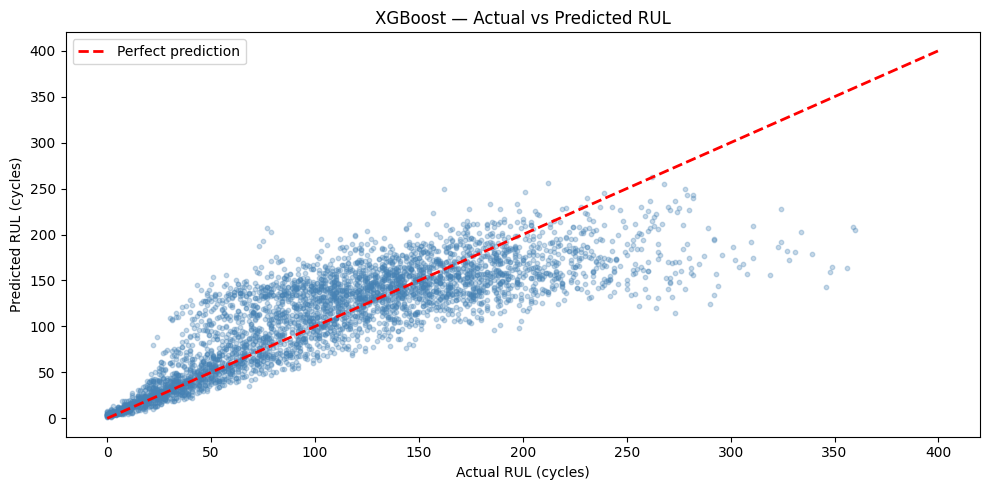

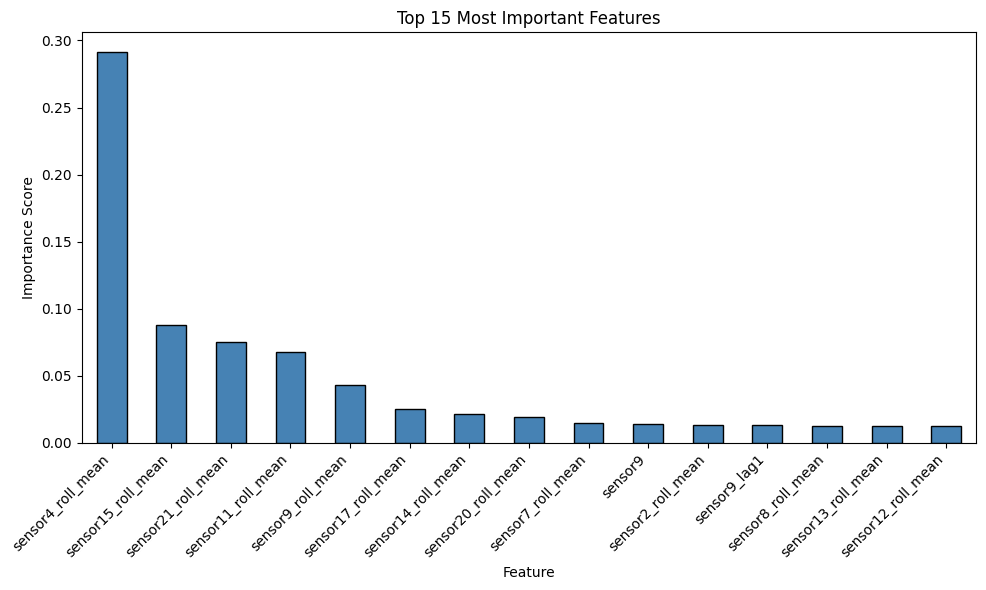

Top 5 most important features:
sensor4_roll_mean     0.291506
sensor15_roll_mean    0.088085
sensor21_roll_mean    0.075236
sensor11_roll_mean    0.067280
sensor9_roll_mean     0.043307
dtype: float32


In [3]:
# Plot 1 — Actual vs Predicted RUL
plt.figure(figsize=(10, 5))
plt.scatter(y_val, y_pred, alpha=0.3, color='steelblue', s=10)
plt.plot([0, 400], [0, 400], 'r--', linewidth=2, label='Perfect prediction')
plt.xlabel('Actual RUL (cycles)')
plt.ylabel('Predicted RUL (cycles)')
plt.title('XGBoost — Actual vs Predicted RUL')
plt.legend()
plt.tight_layout()
plt.show()

# Plot 2 — Top 15 most important features
feat_importance = pd.Series(
    model.feature_importances_, 
    index=X_train.columns
).sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
feat_importance.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Top 15 Most Important Features')
plt.xlabel('Feature')
plt.ylabel('Importance Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("Top 5 most important features:")
print(feat_importance.head())

In [4]:
import pickle

# Save model
with open('../data/processed/xgb_model.pkl', 'wb') as f:
    pickle.dump(model, f)

print("Model saved!")

# Final summary
print("\n" + "="*40)
print("PROJECT SUMMARY SO FAR")
print("="*40)
print(f"Dataset    : NASA CMAPSS FD001")
print(f"Engines    : 100")
print(f"Records    : 20,631")
print(f"Features   : 70 (engineered from 14 sensors)")
print(f"Model      : XGBoost Regressor")
print(f"RMSE       : 36.69 cycles")
print(f"MAE        : 25.94 cycles")
print(f"R²         : 0.7053")
print(f"Tracked in : MLflow")
print("="*40)

# View MLflow UI
print("\nTo view MLflow UI run this in terminal:")
print("cd ~/predictive_maintenance && mlflow ui")
print("Then open: http://127.0.0.1:5000")

Model saved!

PROJECT SUMMARY SO FAR
Dataset    : NASA CMAPSS FD001
Engines    : 100
Records    : 20,631
Features   : 70 (engineered from 14 sensors)
Model      : XGBoost Regressor
RMSE       : 36.69 cycles
MAE        : 25.94 cycles
R²         : 0.7053
Tracked in : MLflow

To view MLflow UI run this in terminal:
cd ~/predictive_maintenance && mlflow ui
Then open: http://127.0.0.1:5000


In [5]:
import os
print("MLflow tracking URI:", mlflow.get_tracking_uri())
print("MLflow runs location:", os.path.abspath("mlruns"))

MLflow tracking URI: sqlite:////Users/singam/predictive_maintenance/notebooks/mlflow.db
MLflow runs location: /Users/singam/predictive_maintenance/notebooks/mlruns
